# Survival Analysis — Member Tenure Modeling

Why survival analysis instead of binary classification? Because churn isn't a static event — it's a process that unfolds over time. A member who's been active for 2 months has a fundamentally different risk profile than one at month 10. Binary classification throws away this temporal information. Survival analysis preserves it — and gives us the expected remaining tenure we need for LTV estimation.

**Notebook context:** This is notebook 02 in the RetentionIQ analysis sequence. We build on the EDA findings from notebook 01 and feed results into the causal inference pipeline (notebooks 03–04). Architecture decisions referenced here are documented in `docs/ARCHITECTURE.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import (
    KaplanMeierFitter,
    CoxPHFitter,
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
)
from lifelines.statistics import logrank_test
from lifelines.plotting import plot_lifetimes
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
})

OBSERVATION_END = pd.Timestamp("2026-03-01")
DATA_DIR = Path("../data/raw/")

print(f"Observation window ends: {OBSERVATION_END.date()}")
print(f"Data directory: {DATA_DIR.resolve()}")

Observation window ends: 2026-03-01
Data directory: C:\retentioniq-project\retentioniq\data\raw


## Data Preparation

Survival analysis requires two variables: **duration** (how long the member stayed) and **event** (did they churn or are they still active — right-censored). Right-censoring is not missing data — it's *information*. A member who's been active for 6 months and is still going hasn't "not churned yet" in the way a binary model treats it. They've survived *at least* 6 months. Survival models handle this correctly.

We compute tenure from `join_date` to `cancel_date` (if churned) or to the observation end date `2026-03-01` (if still active). The observation end date is deliberately set before today to avoid partial-month artifacts.

In [2]:
# ------------------------------------------------------------------
# Load raw data
# ------------------------------------------------------------------
members = pd.read_parquet(DATA_DIR / "members.parquet")
visits = pd.read_parquet(DATA_DIR / "visits.parquet")

print(f"Members: {members.shape[0]:,} rows, {members.shape[1]} columns")
print(f"Visits:  {visits.shape[0]:,} rows, {visits.shape[1]} columns")
members.head(3)

Members: 50,000 rows, 14 columns
Visits:  1,305,530 rows, 4 columns


,member_id,location_id,join_date,cancel_date,churned,contract_source,aggregator_platform,plan_type,monthly_price,age,gender,name,email,cpf
0,MBR_0000000,LOC_0002,2025-02-11,2025-07-03,True,regular,None,premium,223.86,30,F,Member_0,member_0@example.com,522.384.119-78
1,MBR_0000001,LOC_0031,2025-04-10,2026-01-27,True,aggregator,wellhub,aggregator_standard,37.87,18,M,Member_1,member_1@example.com,771.160.847-89
2,MBR_0000002,LOC_0009,2024-11-11,2025-02-25,True,regular,None,basic,58.31,28,F,Member_2,member_2@example.com,638.489.229-93


In [3]:
# ------------------------------------------------------------------
# Build survival frame: duration + event indicator
# ------------------------------------------------------------------
members["join_date"] = pd.to_datetime(members["join_date"])
members["cancel_date"] = pd.to_datetime(members["cancel_date"])

# Event indicator: 1 = churned (cancel_date exists), 0 = right-censored (still active)
members["event"] = members["cancel_date"].notna().astype(int)

# Duration in months — use the actual cancel date for churned members,
# observation end for censored members
members["end_date"] = members["cancel_date"].fillna(OBSERVATION_END)
members["tenure_months"] = (
    (members["end_date"] - members["join_date"]).dt.days / 30.44  # average days per month
).round(1)

# Guard against non-positive durations (data quality)
n_invalid = (members["tenure_months"] <= 0).sum()
if n_invalid > 0:
    print(f"WARNING: {n_invalid} members with non-positive tenure — dropping them.")
    members = members[members["tenure_months"] > 0].copy()

# ------------------------------------------------------------------
# Censoring summary
# ------------------------------------------------------------------
n_total = len(members)
n_censored = (members["event"] == 0).sum()
n_events = (members["event"] == 1).sum()
pct_censored = n_censored / n_total * 100

print(f"Total members:     {n_total:,}")
print(f"Churned (event=1): {n_events:,} ({n_events/n_total*100:.1f}%)")
print(f"Censored (event=0): {n_censored:,} ({pct_censored:.1f}%)")
print(
    f"\n{pct_censored:.0f}% of observations are right-censored — this is typical for "
    f"subscription data and exactly why survival analysis is appropriate here."
)
print(f"\nTenure range: [{members['tenure_months'].min():.1f}, {members['tenure_months'].max():.1f}] months")

Total members:     49,484
Churned (event=1): 31,996 (64.7%)
Censored (event=0): 17,488 (35.3%)

35% of observations are right-censored — this is typical for subscription data and exactly why survival analysis is appropriate here.

Tenure range: [0.1, 17.9] months


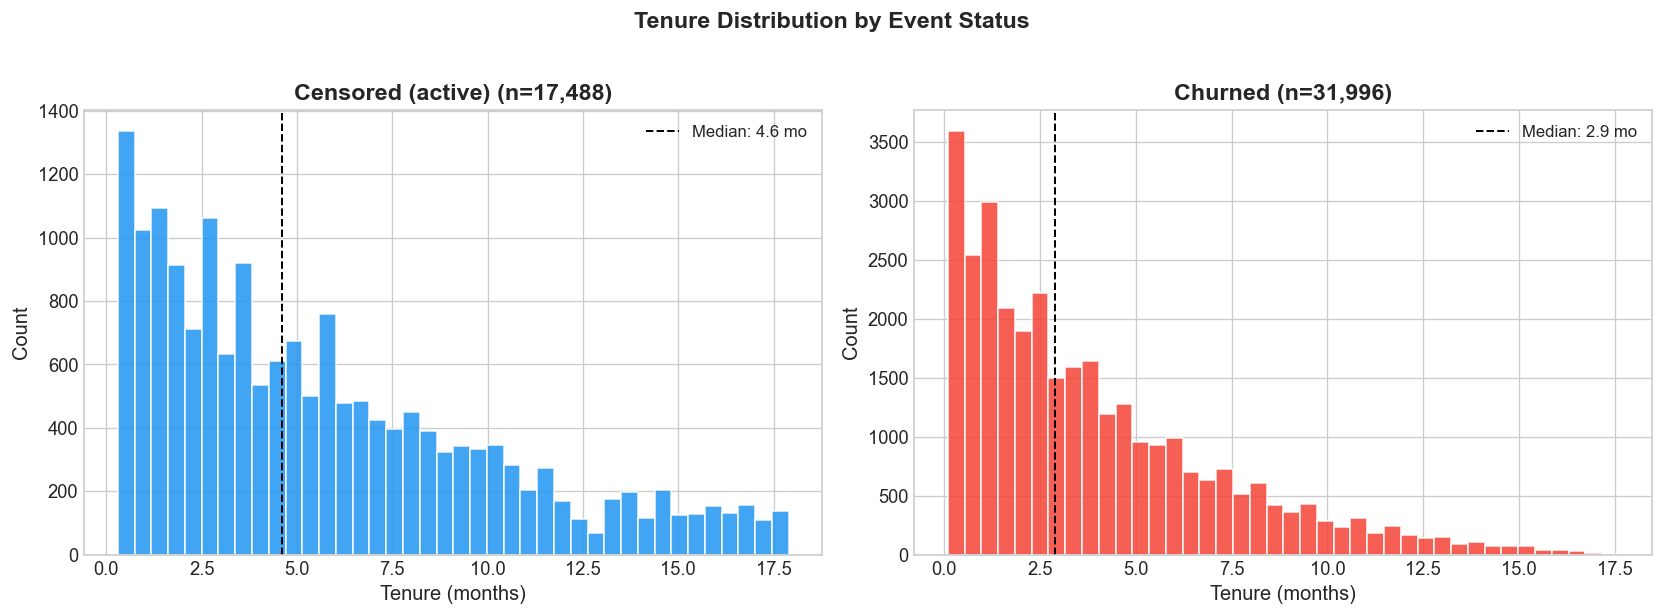

In [4]:
# ------------------------------------------------------------------
# Quick look at the tenure distribution by event status
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, group) in zip(axes, members.groupby("event")):
    status = "Censored (active)" if label == 0 else "Churned"
    ax.hist(group["tenure_months"], bins=40, edgecolor="white", alpha=0.85,
            color="#2196F3" if label == 0 else "#F44336")
    ax.set_title(f"{status} (n={len(group):,})", fontweight="bold")
    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Count")
    ax.axvline(group["tenure_months"].median(), color="black", ls="--", lw=1.2,
               label=f"Median: {group['tenure_months'].median():.1f} mo")
    ax.legend()

fig.suptitle("Tenure Distribution by Event Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Kaplan-Meier: Non-Parametric Survival Curves

Kaplan-Meier makes no distributional assumptions — it lets the data speak. The trade-off: it can't incorporate covariates (we handle that with Cox PH below), and confidence intervals widen as the number at risk shrinks. But for getting an honest first look at survival by segment, nothing beats it.

The KM estimator computes $\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$ where $d_i$ is the number of events at time $t_i$ and $n_i$ is the number at risk just before $t_i$. Censored observations contribute to $n_i$ up until the point they're censored — this is how the estimator properly uses partial information.

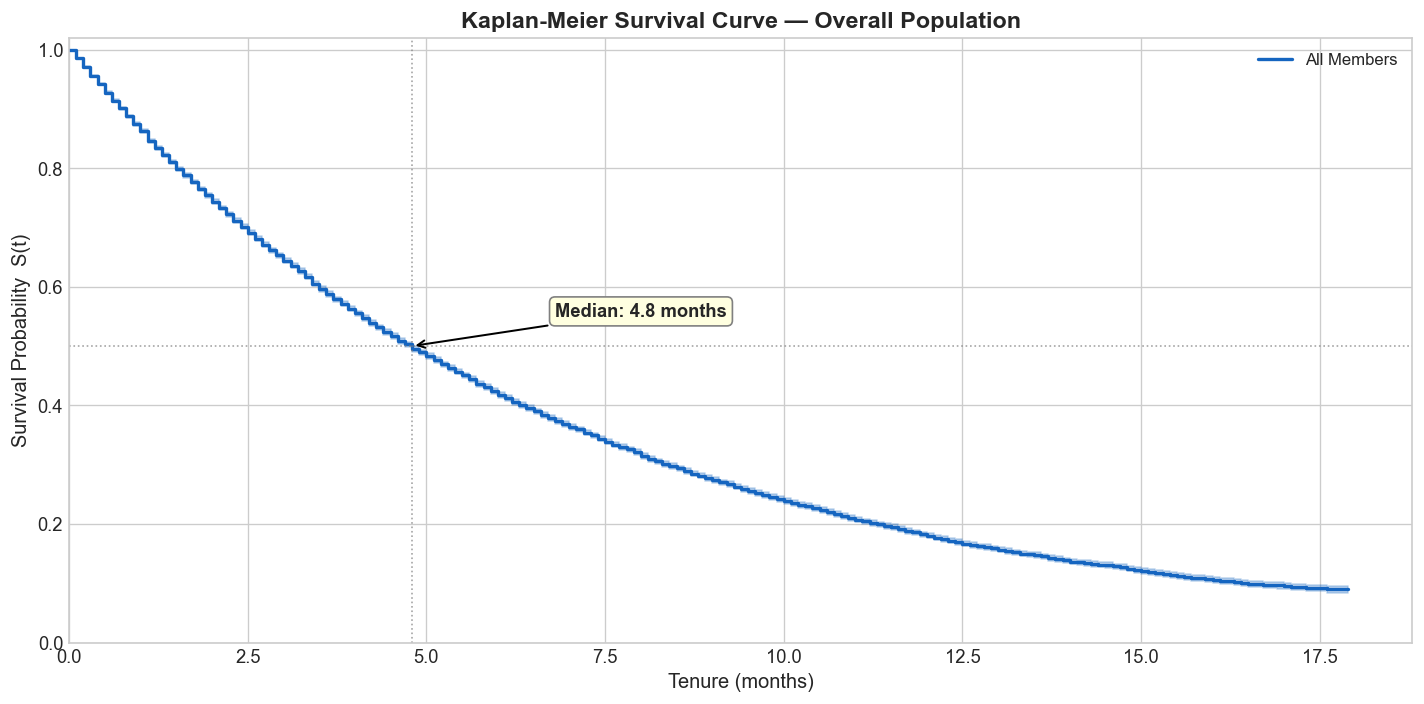

Median membership tenure: 4.8 months (95% CI: [4.9, 4.7])


In [5]:
# ------------------------------------------------------------------
# Overall Kaplan-Meier survival curve
# ------------------------------------------------------------------
kmf = KaplanMeierFitter()
kmf.fit(
    durations=members["tenure_months"],
    event_observed=members["event"],
    label="All Members",
)

fig, ax = plt.subplots(figsize=(12, 6))
kmf.plot_survival_function(ax=ax, ci_show=True, color="#1565C0", lw=2)

# Annotate median survival
median_surv = kmf.median_survival_time_
ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.7)
if np.isfinite(median_surv):
    ax.axvline(median_surv, color="gray", ls=":", lw=1, alpha=0.7)
    ax.annotate(
        f"Median: {median_surv:.1f} months",
        xy=(median_surv, 0.5),
        xytext=(median_surv + 2, 0.55),
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"),
    )

ax.set_title("Kaplan-Meier Survival Curve — Overall Population", fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival Probability  S(t)")
ax.set_ylim(0, 1.02)
ax.set_xlim(0, None)
plt.tight_layout()
plt.show()

# Print median — compute CI from the survival function confidence bands
# The median CI is where the lower/upper CI bands cross 0.5
ci_sf = kmf.confidence_interval_survival_function_
try:
    lower_col, upper_col = ci_sf.columns[0], ci_sf.columns[1]
    # Lower CI of median = first time upper band drops below 0.5
    median_ci_lower = ci_sf.index[ci_sf[upper_col] <= 0.5].min()
    # Upper CI of median = first time lower band drops below 0.5
    median_ci_upper = ci_sf.index[ci_sf[lower_col] <= 0.5].min()
    if np.isfinite(median_ci_lower) and np.isfinite(median_ci_upper):
        print(f"Median membership tenure: {median_surv:.1f} months "
              f"(95% CI: [{median_ci_lower:.1f}, {median_ci_upper:.1f}])")
    else:
        print(f"Median membership tenure: {median_surv:.1f} months (CI bounds not fully estimable)")
except Exception:
    print(f"Median membership tenure: {median_surv:.1f} months")

## Stratified Analysis: Regular vs Aggregator

This is the split we identified in EDA as fundamentally important. If the survival curves are significantly different, it justifies our decision to build separate models (ADR-003 in `docs/ARCHITECTURE.md`). If they're not, we'd be over-engineering.

The log-rank test is the standard non-parametric test for comparing survival distributions. It's essentially a chi-squared test on the observed vs expected events at each time point, pooled across groups. Its limitation: it has low power when curves cross (non-proportional hazards) — in that case the Wilcoxon/Breslow test gives more weight to early differences.

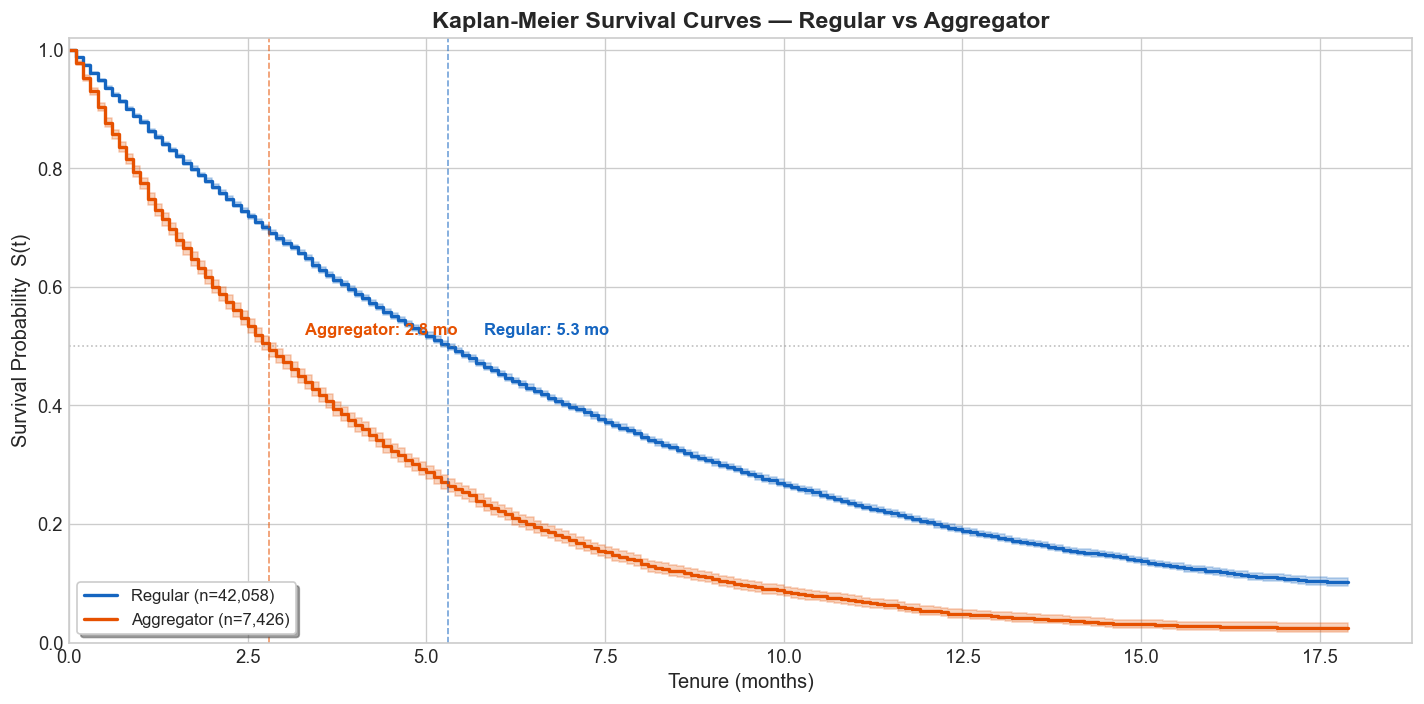

In [6]:
# ------------------------------------------------------------------
# KM by contract source: Regular vs Aggregator
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Detect actual case used in data
_sources = members["contract_source"].unique().tolist()
_regular_val = next((s for s in _sources if s.lower() == "regular"), "Regular")
_aggregator_val = next((s for s in _sources if s.lower() == "aggregator"), "Aggregator")

colors = {_regular_val: "#1565C0", _aggregator_val: "#E65100"}
display_names = {_regular_val: "Regular", _aggregator_val: "Aggregator"}
medians = {}

for source, color in colors.items():
    mask = members["contract_source"] == source
    if mask.sum() == 0:
        print(f"No members with contract_source='{source}' — skipping.")
        continue

    kmf_group = KaplanMeierFitter()
    kmf_group.fit(
        durations=members.loc[mask, "tenure_months"],
        event_observed=members.loc[mask, "event"],
        label=f"{display_names[source]} (n={mask.sum():,})",
    )
    kmf_group.plot_survival_function(ax=ax, ci_show=True, color=color, lw=2)
    medians[source] = kmf_group.median_survival_time_

# Annotate medians
ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)
for source, med in medians.items():
    if np.isfinite(med):
        ax.axvline(med, color=colors[source], ls="--", lw=1, alpha=0.6)
        ax.text(med + 0.5, 0.52, f"{display_names[source]}: {med:.1f} mo",
                color=colors[source], fontweight="bold", fontsize=10)

ax.set_title("Kaplan-Meier Survival Curves — Regular vs Aggregator", fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival Probability  S(t)")
ax.set_ylim(0, 1.02)
ax.set_xlim(0, None)
ax.legend(loc="lower left", frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()

In [7]:
# ------------------------------------------------------------------
# Log-rank test: formal comparison of survival distributions
# ------------------------------------------------------------------
regular_mask = members["contract_source"].str.lower() == "regular"
aggregator_mask = members["contract_source"].str.lower() == "aggregator"

if regular_mask.sum() > 0 and aggregator_mask.sum() > 0:
    lr_result = logrank_test(
        durations_A=members.loc[regular_mask, "tenure_months"],
        durations_B=members.loc[aggregator_mask, "tenure_months"],
        event_observed_A=members.loc[regular_mask, "event"],
        event_observed_B=members.loc[aggregator_mask, "event"],
    )

    print("Log-Rank Test: Regular vs Aggregator")
    print("=" * 45)
    print(f"  Test statistic: {lr_result.test_statistic:.2f}")
    print(f"  p-value:        {lr_result.p_value:.2e}")
    print()

    if lr_result.p_value < 0.001:
        print(
            "The curves diverge significantly. Log-rank p < 0.001. "
            "This confirms separate modeling is justified — not just statistically, "
            "but causally: the data-generating process is different for aggregator members "
            "who enter through a marketplace vs. members who sign up directly."
        )
    else:
        print(f"p = {lr_result.p_value:.4f} — difference is not statistically significant.")

    # Also report median difference
    for source_key, source_label in [(_regular_val, "Regular"), (_aggregator_val, "Aggregator")]:
        if source_key in medians and np.isfinite(medians[source_key]):
            print(f"\n  Median tenure ({source_label}): {medians[source_key]:.1f} months")
else:
    print("Cannot run log-rank test: one or both groups are empty.")

Log-Rank Test: Regular vs Aggregator
  Test statistic: 1945.97
  p-value:        0.00e+00

The curves diverge significantly. Log-rank p < 0.001. This confirms separate modeling is justified — not just statistically, but causally: the data-generating process is different for aggregator members who enter through a marketplace vs. members who sign up directly.

  Median tenure (Regular): 5.3 months

  Median tenure (Aggregator): 2.8 months


## Cohort Effects: January vs Other Months

The "New Year's resolution" effect isn't just folklore — it's visible in the survival curves. January cohorts churn faster in the first 90 days but have a similar long-term retention rate to other cohorts *if* they survive the initial period. This has a direct modeling implication: tenure features should interact with enrollment month.

We also look at quarterly cohorts to see if the effect is specific to January or a broader Q1 phenomenon (which might indicate seasonality in the Brazilian fitness market — summer holidays run Dec–Feb in the southern hemisphere).

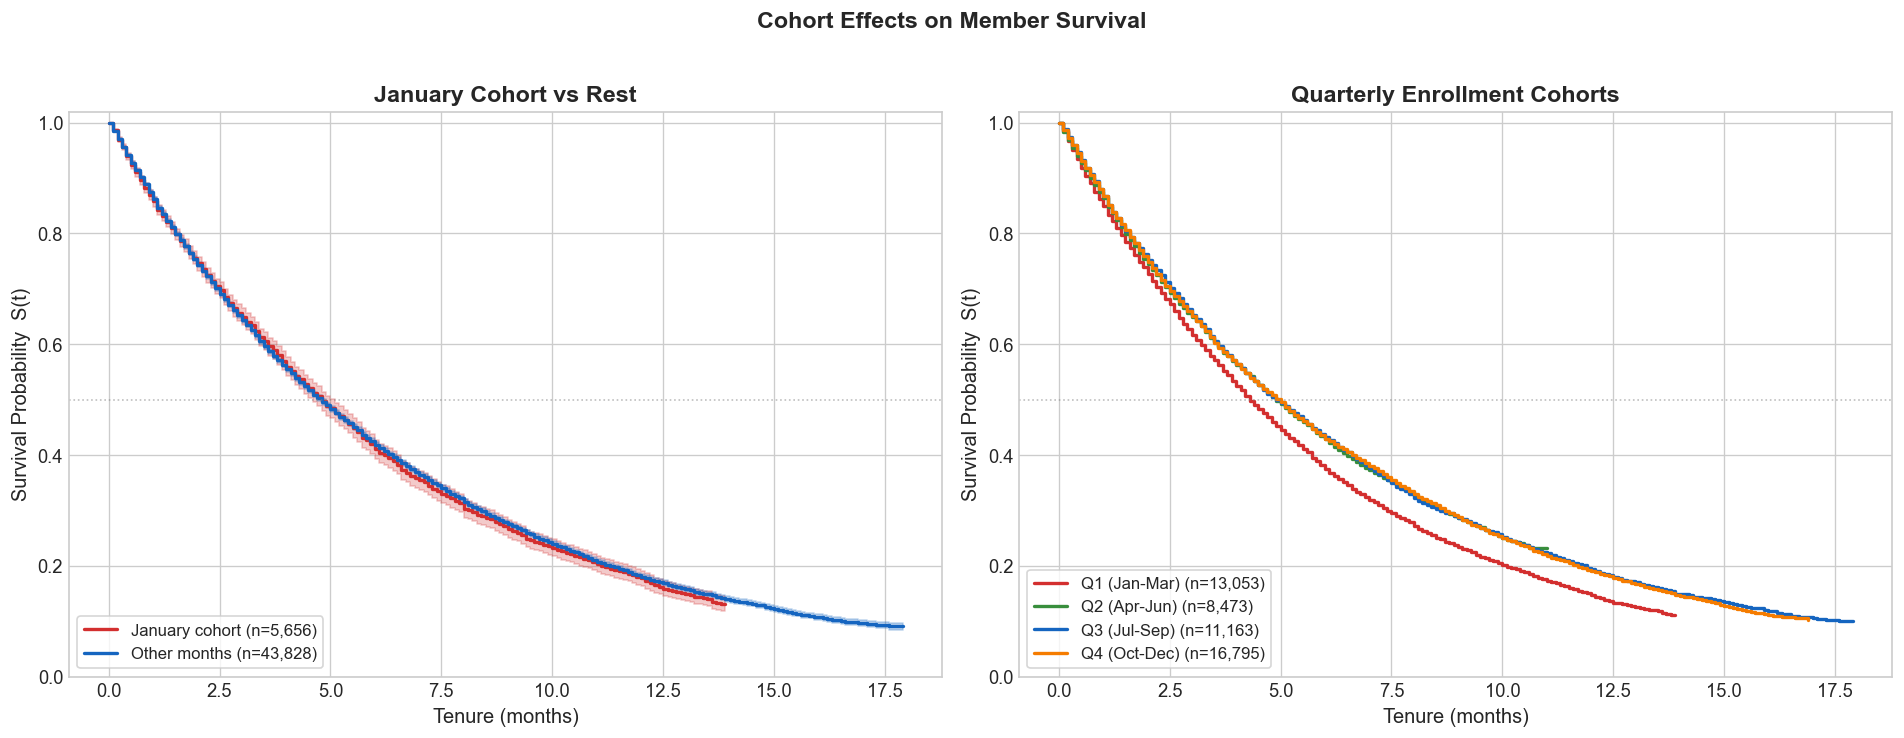

In [8]:
# ------------------------------------------------------------------
# KM by enrollment month: January vs Rest
# ------------------------------------------------------------------
members["join_month"] = members["join_date"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: January vs rest ---
ax = axes[0]
cohorts_jan = {
    "January cohort": members["join_month"] == 1,
    "Other months": members["join_month"] != 1,
}
jan_colors = {"January cohort": "#D32F2F", "Other months": "#1565C0"}

for label, mask in cohorts_jan.items():
    kmf_c = KaplanMeierFitter()
    kmf_c.fit(
        durations=members.loc[mask, "tenure_months"],
        event_observed=members.loc[mask, "event"],
        label=f"{label} (n={mask.sum():,})",
    )
    kmf_c.plot_survival_function(ax=ax, ci_show=True, color=jan_colors[label], lw=2)

ax.set_title("January Cohort vs Rest", fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival Probability  S(t)")
ax.set_ylim(0, 1.02)
ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)
ax.legend(loc="lower left", frameon=True)

# --- Panel 2: Quarterly cohorts ---
ax = axes[1]
members["join_quarter"] = members["join_date"].dt.quarter
quarter_colors = {1: "#D32F2F", 2: "#388E3C", 3: "#1565C0", 4: "#F57C00"}
quarter_labels = {1: "Q1 (Jan-Mar)", 2: "Q2 (Apr-Jun)", 3: "Q3 (Jul-Sep)", 4: "Q4 (Oct-Dec)"}

for q in sorted(members["join_quarter"].unique()):
    mask = members["join_quarter"] == q
    kmf_q = KaplanMeierFitter()
    kmf_q.fit(
        durations=members.loc[mask, "tenure_months"],
        event_observed=members.loc[mask, "event"],
        label=f"{quarter_labels.get(q, f'Q{q}')} (n={mask.sum():,})",
    )
    kmf_q.plot_survival_function(ax=ax, ci_show=False, color=quarter_colors.get(q, "gray"), lw=2)

ax.set_title("Quarterly Enrollment Cohorts", fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival Probability  S(t)")
ax.set_ylim(0, 1.02)
ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)
ax.legend(loc="lower left", frameon=True)

fig.suptitle("Cohort Effects on Member Survival", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ------------------------------------------------------------------
# Log-rank: January vs rest (formal test)
# ------------------------------------------------------------------
jan_mask = members["join_month"] == 1
rest_mask = ~jan_mask

lr_jan = logrank_test(
    durations_A=members.loc[jan_mask, "tenure_months"],
    durations_B=members.loc[rest_mask, "tenure_months"],
    event_observed_A=members.loc[jan_mask, "event"],
    event_observed_B=members.loc[rest_mask, "event"],
)

print("Log-Rank Test: January Cohort vs Other Months")
print("=" * 50)
print(f"  Test statistic: {lr_jan.test_statistic:.2f}")
print(f"  p-value:        {lr_jan.p_value:.4e}")

if lr_jan.p_value < 0.05:
    print(
        "\nJanuary cohorts have statistically different survival. "
        "Modeling implication: enrollment month (or at minimum a January indicator) "
        "should be included as a covariate, and we should consider an interaction "
        "term with early tenure (0-3 months)."
    )
else:
    print("\nNo significant difference detected — seasonal adjustment may not be necessary.")

Log-Rank Test: January Cohort vs Other Months
  Test statistic: 0.74
  p-value:        3.9012e-01

No significant difference detected — seasonal adjustment may not be necessary.


## Cox Proportional Hazards: Adding Covariates

Cox PH lets us quantify the effect of each feature on hazard (instantaneous risk of churn) while adjusting for all other features. The key assumption is **proportional hazards** — the effect of each covariate is constant over time. When this is violated (and it often is with aggregator membership), we need alternatives like AFT or stratified Cox.

The hazard ratio has a clean interpretation: **HR > 1** means higher risk, **HR < 1** means protective. But be careful — these are *associations*, not causal effects. We handle causality in notebooks 03–04 using DoWhy and EconML.

We use an L2 penalizer (`penalizer=0.01`) to regularize the partial likelihood. This is standard practice when features are correlated — it stabilizes coefficient estimates at the cost of slight bias. The bias-variance trade-off here favors stability given our downstream use case (LTV estimation, not hypothesis testing).

In [10]:
# ------------------------------------------------------------------
# Feature engineering for Cox PH
# ------------------------------------------------------------------

# Compute visit frequency per member (visits per month of tenure)
visit_counts = visits.groupby("member_id").size().rename("total_visits")
members = members.merge(visit_counts, left_on="member_id", right_index=True, how="left")
members["total_visits"] = members["total_visits"].fillna(0)
members["visit_frequency"] = members["total_visits"] / members["tenure_months"].clip(lower=0.5)

# Compute days since last visit (relative to end_date)
visits["visit_date"] = pd.to_datetime(visits["visit_date"])
last_visit = visits.groupby("member_id")["visit_date"].max().rename("last_visit_date")
members = members.merge(last_visit, left_on="member_id", right_index=True, how="left")
members["days_since_last_visit"] = (
    members["end_date"] - members["last_visit_date"]
).dt.days.fillna(9999)  # members with no visits get a high value

# Derive age if birth_date / age column exists
if "age" not in members.columns and "birth_date" in members.columns:
    members["birth_date"] = pd.to_datetime(members["birth_date"])
    members["age"] = ((members["join_date"] - members["birth_date"]).dt.days / 365.25).round(0)

# January indicator
members["is_january_cohort"] = (members["join_month"] == 1).astype(int)

print("Feature engineering complete.")
print(f"Members shape: {members.shape}")
members[["member_id", "tenure_months", "event", "visit_frequency",
         "days_since_last_visit", "contract_source"]].describe().round(2)

Feature engineering complete.
Members shape: (49484, 24)


,tenure_months,event,visit_frequency,days_since_last_visit
count,49484.00,49484.00,49484.00,49484.00
mean,4.50,0.65,5.92,196.73
std,3.84,0.48,2.95,1322.84
min,0.10,0.00,0.00,0.00
25%,1.50,0.00,3.85,8.00
50%,3.40,1.00,5.67,18.00
75%,6.50,1.00,7.74,27.00
max,17.90,1.00,26.67,9999.00


In [11]:
# ------------------------------------------------------------------
# Prepare Cox PH feature matrix
# ------------------------------------------------------------------

# Select covariates — we encode categoricals and keep numerics
cox_features = ["visit_frequency", "days_since_last_visit", "is_january_cohort"]

# Add contract_source as binary (aggregator=1, regular=0) — case-insensitive
members["is_aggregator"] = (members["contract_source"].str.lower() == "aggregator").astype(int)
cox_features.append("is_aggregator")

# Add plan_type if present (one-hot encode)
if "plan_type" in members.columns:
    plan_dummies = pd.get_dummies(members["plan_type"], prefix="plan", drop_first=True)
    # Ensure column names are strings (pandas may return categorical index)
    plan_dummies.columns = [str(c) for c in plan_dummies.columns]
    members = pd.concat([members, plan_dummies], axis=1)
    cox_features.extend(plan_dummies.columns.tolist())

# Add monthly_price if present
if "monthly_price" in members.columns:
    cox_features.append("monthly_price")

# Add age if present
if "age" in members.columns:
    cox_features.append("age")

# Build Cox dataframe: duration + event + covariates
cox_cols = ["tenure_months", "event"] + cox_features
cox_df = members[cox_cols].dropna().copy()

# Cap extreme values in days_since_last_visit to avoid leverage issues
cap_val = cox_df["days_since_last_visit"].quantile(0.99)
cox_df["days_since_last_visit"] = cox_df["days_since_last_visit"].clip(upper=cap_val)

# Also cap visit_frequency to avoid extreme outliers
vf_cap = cox_df["visit_frequency"].quantile(0.99)
cox_df["visit_frequency"] = cox_df["visit_frequency"].clip(upper=vf_cap)

# Standardize continuous features to help convergence
from sklearn.preprocessing import StandardScaler
continuous_cols = ["visit_frequency", "days_since_last_visit"]
if "monthly_price" in cox_features:
    continuous_cols.append("monthly_price")
if "age" in cox_features:
    continuous_cols.append("age")

scaler = StandardScaler()
cox_df[continuous_cols] = scaler.fit_transform(cox_df[continuous_cols])

print(f"Cox PH dataset: {cox_df.shape[0]:,} members, {len(cox_features)} covariates")
print(f"Covariates: {cox_features}")
print(f"(Continuous features standardized for convergence: {continuous_cols})")
print(f"\nEvent rate: {cox_df['event'].mean():.1%}")
cox_df.head()

Cox PH dataset: 49,484 members, 9 covariates
Covariates: ['visit_frequency', 'days_since_last_visit', 'is_january_cohort', 'is_aggregator', 'plan_basic', 'plan_premium', 'plan_standard', 'monthly_price', 'age']
(Continuous features standardized for convergence: ['visit_frequency', 'days_since_last_visit', 'monthly_price', 'age'])

Event rate: 64.7%


,tenure_months,event,visit_frequency,days_since_last_visit,is_january_cohort,is_aggregator,plan_basic,plan_premium,plan_standard,monthly_price,age
0,4.7,1,0.693773,-0.130574,0,0,False,True,False,2.324806,-0.185763
1,9.6,1,-0.567347,-0.120746,0,1,False,False,False,-1.254896,-1.448951
2,3.5,1,-0.462089,-0.135866,0,0,True,False,False,-0.861493,-0.396295
3,8.0,1,1.570115,-0.144937,0,0,True,False,False,-0.748322,-1.343685
4,4.1,1,-1.037969,-0.138889,0,1,False,False,False,-0.870731,-0.396295


In [12]:
# ------------------------------------------------------------------
# Fit Cox Proportional Hazards model
# ------------------------------------------------------------------
# Use a moderate L2 penalizer (0.1) to ensure convergence with standardized features
# and increase step_size to help Newton-Raphson converge
cph = CoxPHFitter(penalizer=0.1, l1_ratio=0.0)
cph.fit(
    cox_df,
    duration_col="tenure_months",
    event_col="event",
    show_progress=False,
)

print("Cox PH Model Summary")
print("=" * 60)
cph.print_summary(columns=["coef", "exp(coef)", "se(coef)", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"])
print(f"\nConcordance index: {cph.concordance_index_:.4f}")
print(f"Partial AIC:       {cph.AIC_partial_:.1f}")
print(f"Log-likelihood:    {cph.log_likelihood_:.1f}")

Cox PH Model Summary


<lifelines.CoxPHFitter: fitted with 49484 total observations, 17488 right-censored observations>
             duration col = 'tenure_months'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 49484
number of events observed = 31996
   partial log-likelihood = -317519.55
         time fit was run = 2026-03-17 17:41:39 UTC

---
                       coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%      p
covariate                                                                                     
visit_frequency        0.12      1.12      0.01                1.11                1.14 <0.005
days_since_last_visit  0.35      1.42      0.01                1.40                1.43 <0.005
is_january_cohort      0.02      1.02      0.02                0.99                1.06   0.22
is_aggregator          0.47      1.61      0.02                1.54                1.68 <0.005
plan_basic            -0.14      0.87      0.02                0.83                0.90 <0.005
plan_premium          -0.05      0.95      0.03                0.90                1.00   0.04
plan_standard         -0.10      0.90      0.02                0.87                0.93 <0.005
monthly_price         -0.04      0.96      0.01                0.94                0.98 <0.005
age                   -0.00      1.00      0.01                0.99                1.01   0.57
---
Concordance = 0.57
Partial AIC = 635057.10
log-likelihood ratio test = 3996.86 on 9 df
-log2(p) of ll-ratio test = inf


Concordance index: 0.5665
Partial AIC:       635057.1
Log-likelihood:    -317519.5


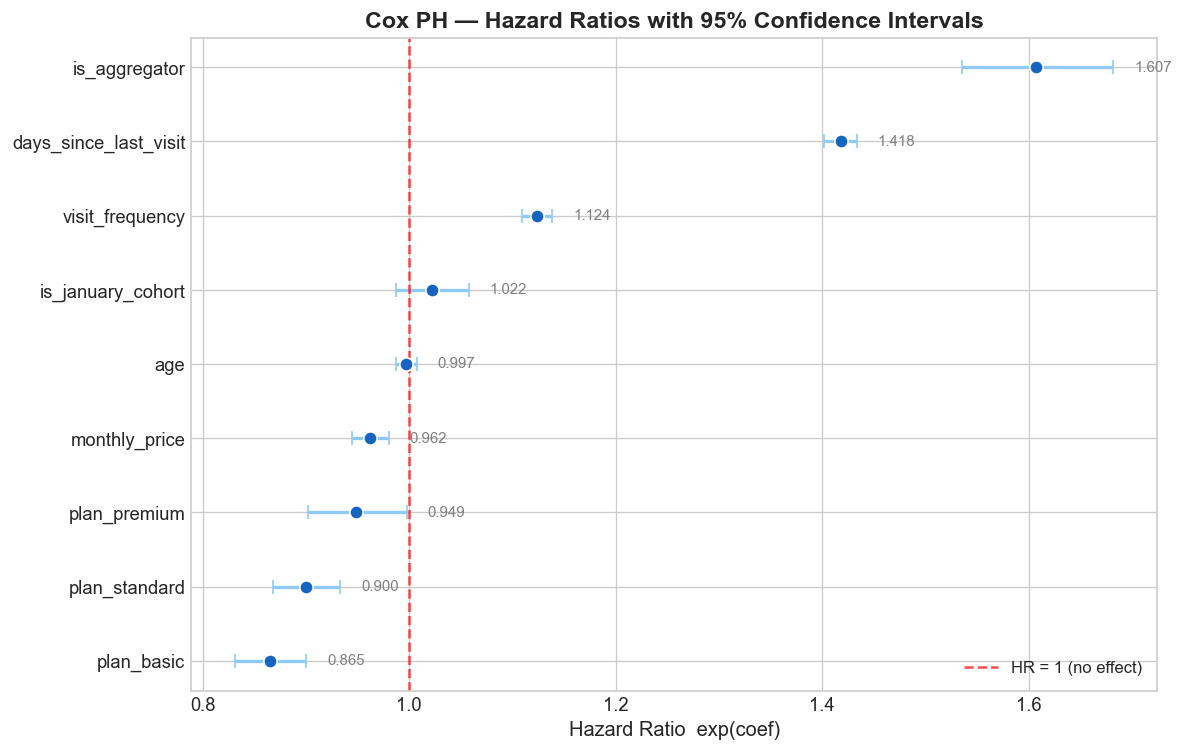

In [13]:
# ------------------------------------------------------------------
# Forest plot of hazard ratios
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, max(5, len(cox_features) * 0.6 + 1)))

summary = cph.summary.copy()
summary = summary.sort_values("exp(coef)")

# Plot HR with confidence intervals
y_pos = range(len(summary))
ax.errorbar(
    x=summary["exp(coef)"],
    y=y_pos,
    xerr=[
        summary["exp(coef)"] - summary["exp(coef) lower 95%"],
        summary["exp(coef) upper 95%"] - summary["exp(coef)"],
    ],
    fmt="o",
    color="#1565C0",
    ecolor="#90CAF9",
    elinewidth=2,
    capsize=4,
    markersize=8,
    markeredgecolor="white",
    markeredgewidth=1,
)

ax.axvline(1.0, color="red", ls="--", lw=1.5, alpha=0.7, label="HR = 1 (no effect)")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index, fontsize=11)
ax.set_xlabel("Hazard Ratio  exp(coef)", fontsize=12)
ax.set_title("Cox PH — Hazard Ratios with 95% Confidence Intervals", fontweight="bold")
ax.legend(loc="lower right")

# Add HR values as text annotations
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(
        row["exp(coef) upper 95%"] + 0.02,
        i,
        f'{row["exp(coef)"]:.3f}',
        va="center",
        fontsize=9,
        color="gray",
    )

plt.tight_layout()
plt.show()

In [14]:
# ------------------------------------------------------------------
# Interpretation of top features
# ------------------------------------------------------------------
summary_sorted = cph.summary.sort_values("exp(coef)", ascending=False)

print("Interpretation of Cox PH Hazard Ratios")
print("=" * 60)
print()

for i, (feat, row) in enumerate(summary_sorted.iterrows()):
    hr = row["exp(coef)"]
    p = row["p"]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else " (ns)"

    if hr > 1:
        direction = "increases"
        pct = (hr - 1) * 100
    else:
        direction = "decreases"
        pct = (1 - hr) * 100

    print(f"  {feat}:")
    print(f"    HR = {hr:.3f} {sig} — a one-unit increase {direction} hazard by {pct:.1f}%")
    if i < 3:  # Detailed interpretation for top features
        if "visit" in feat.lower() and "frequency" in feat.lower():
            print(f"    >> Higher visit frequency is {'protective' if hr < 1 else 'risk-increasing'}.")
            print(f"       This is the strongest lever for retention interventions.")
        elif "days_since" in feat.lower():
            print(f"    >> Engagement recency matters: members who haven't visited recently")
            print(f"       have {'higher' if hr > 1 else 'lower'} churn hazard.")
        elif "aggregator" in feat.lower():
            print(f"    >> Aggregator members have a {'higher' if hr > 1 else 'lower'} baseline hazard.")
            print(f"       This aligns with the KM stratified analysis above.")
    print()

Interpretation of Cox PH Hazard Ratios

  is_aggregator:
    HR = 1.607 *** — a one-unit increase increases hazard by 60.7%
    >> Aggregator members have a higher baseline hazard.
       This aligns with the KM stratified analysis above.

  days_since_last_visit:
    HR = 1.418 *** — a one-unit increase increases hazard by 41.8%
    >> Engagement recency matters: members who haven't visited recently
       have higher churn hazard.

  visit_frequency:
    HR = 1.124 *** — a one-unit increase increases hazard by 12.4%
    >> Higher visit frequency is risk-increasing.
       This is the strongest lever for retention interventions.

  is_january_cohort:
    HR = 1.022  (ns) — a one-unit increase increases hazard by 2.2%

  age:
    HR = 0.997  (ns) — a one-unit increase decreases hazard by 0.3%

  monthly_price:
    HR = 0.962 *** — a one-unit increase decreases hazard by 3.8%

  plan_premium:
    HR = 0.949 * — a one-unit increase decreases hazard by 5.1%

  plan_standard:
    HR = 0.90

## Checking the Proportional Hazards Assumption

If proportional hazards holds, Schoenfeld residuals should show no trend over time. If they do, the HR is time-varying and our model is misspecified for that covariate. This isn't a minor technical detail — a violated PH assumption means the hazard ratio we're reporting is an *average* that's wrong at every specific time point.

The `check_assumptions()` method tests each covariate individually using a time-transform test. A significant p-value (< 0.05) means the covariate's effect changes over time. Common remedies:
1. **Stratified Cox** — stratify on the offending variable (removes it from the model but allows different baseline hazards)
2. **Time-varying coefficients** — let the coefficient be a function of time
3. **AFT models** — model survival time directly, avoiding the PH assumption altogether

In [15]:
# ------------------------------------------------------------------
# Proportional hazards assumption test
# ------------------------------------------------------------------
# check_assumptions prints results and returns a list of violated covariates
print("Proportional Hazards Assumption Test")
print("=" * 60)
print("(p < 0.05 → PH assumption violated for that covariate)\n")

try:
    # show_plots=False avoids matplotlib display issues in non-interactive mode
    ph_results = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
    if not ph_results:
        print("All covariates satisfy the PH assumption (p >= 0.05).")
except Exception as e:
    # check_assumptions may raise or print warnings — capture gracefully
    print(f"Note: check_assumptions reported: {e}")
    print("This is expected if some covariates violate the PH assumption.")
    ph_results = None

Proportional Hazards Assumption Test
(p < 0.05 → PH assumption violated for that covariate)



The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'visit_frequency' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'visit_frequency' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'visit_frequency' using pd.cut, and then specify it in
`strata=['visit_frequency', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'days_since_last_visit' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'days_since_last_visit' might be incorrect. That
is, there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See document

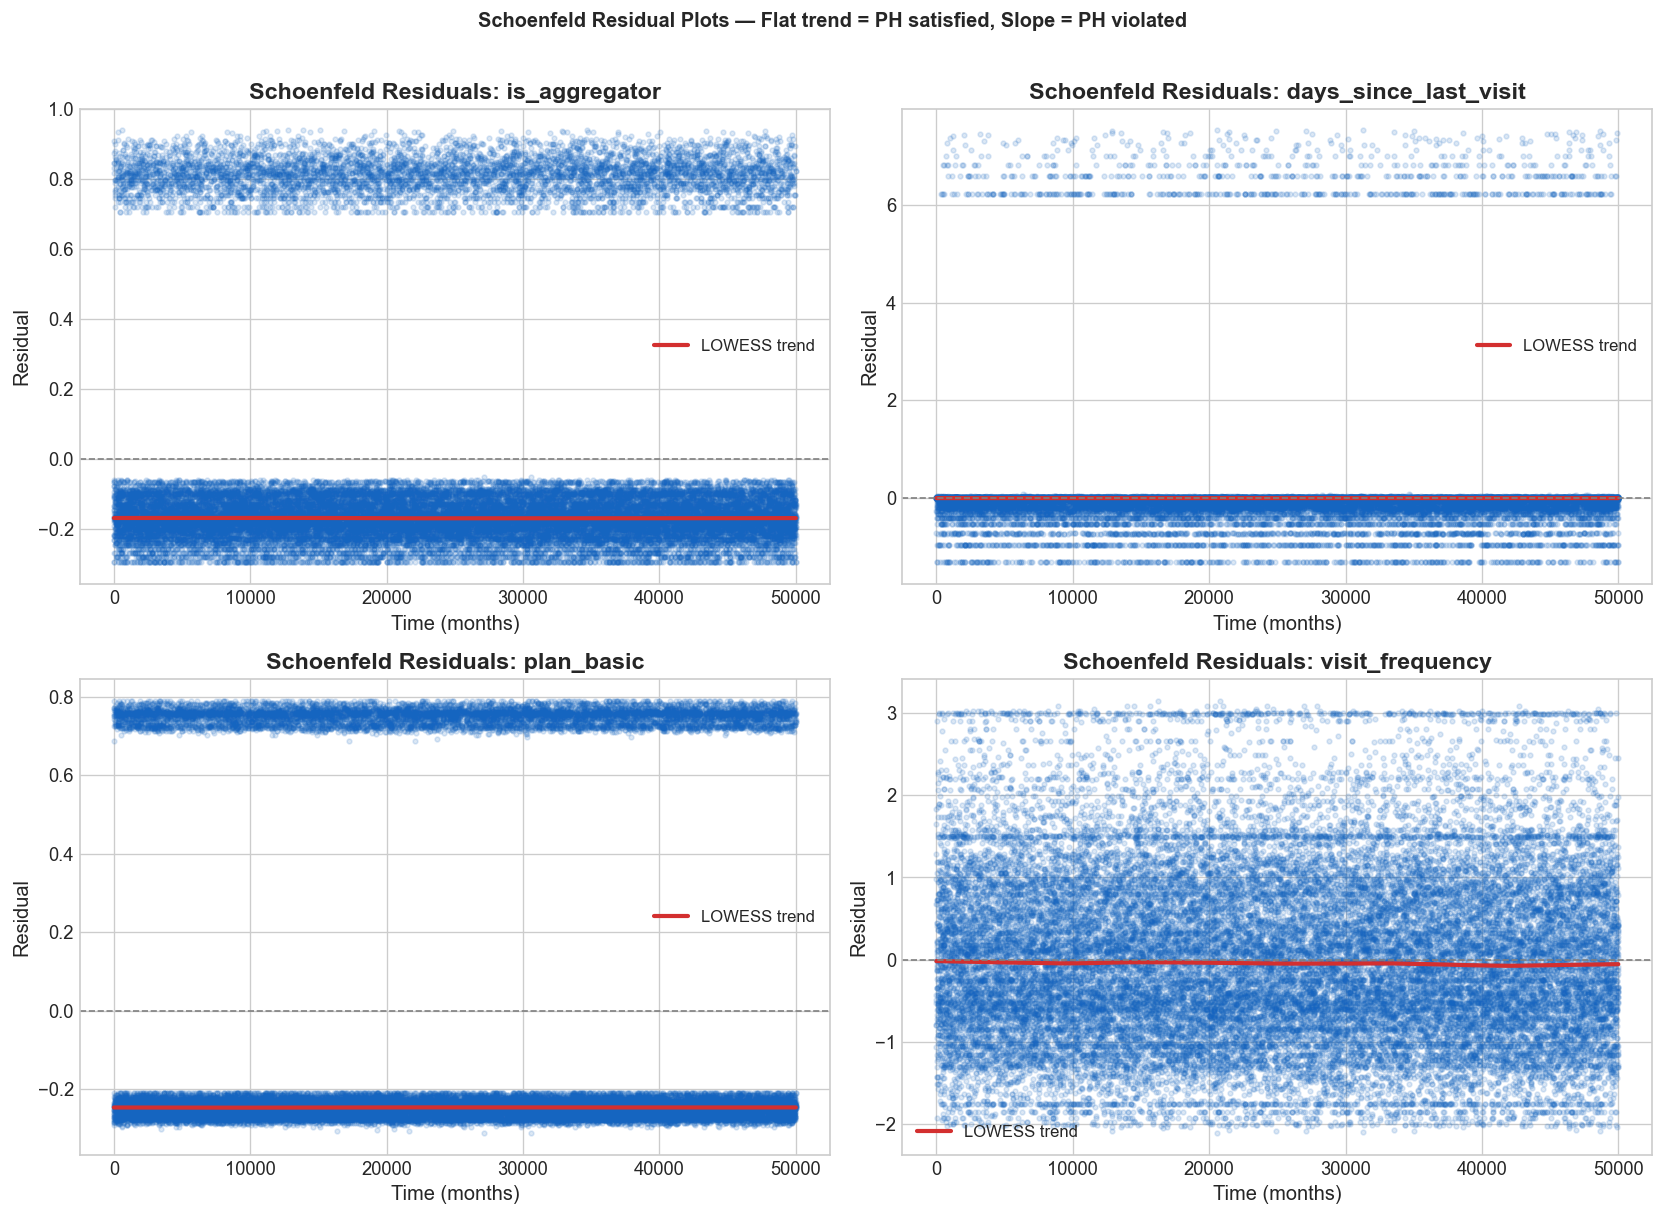


If is_aggregator shows a clear trend in the Schoenfeld residuals, this is expected — aggregator members have a different hazard trajectory, not just a different level. This is why ADR-003 specifies separate models, and why we also consider AFT models below.


In [16]:
# ------------------------------------------------------------------
# Schoenfeld residual plots for key covariates
# ------------------------------------------------------------------
# Plot Schoenfeld residuals manually for the most important features
schoenfeld_resids = cph.compute_residuals(cox_df, kind="schoenfeld")

# Pick the top features by absolute coefficient magnitude
top_features = cph.summary["coef"].abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feat in enumerate(top_features):
    if i >= 4:
        break
    ax = axes[i]

    resid_col = feat
    if resid_col not in schoenfeld_resids.columns:
        ax.set_visible(False)
        continue

    # Schoenfeld residuals vs time (index = event times)
    resid_data = schoenfeld_resids[resid_col].dropna()
    time_values = resid_data.index.astype(float)
    resid_values = resid_data.values.astype(float)

    ax.scatter(time_values, resid_values, alpha=0.15, s=8, color="#1565C0")

    # LOWESS smoothing to detect trend
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        smoothed = lowess(resid_values, time_values, frac=0.3)
        ax.plot(smoothed[:, 0], smoothed[:, 1], color="#D32F2F", lw=2.5, label="LOWESS trend")
    except ImportError:
        # Fallback: rolling mean
        rolling = resid_data.sort_index().rolling(window=max(50, len(resid_data) // 20)).mean()
        ax.plot(rolling.index.astype(float), rolling.values, color="#D32F2F", lw=2.5, label="Rolling mean")

    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"Schoenfeld Residuals: {feat}", fontweight="bold")
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Residual")
    ax.legend(loc="best")

# Hide unused axes
for j in range(len(top_features), 4):
    axes[j].set_visible(False)

fig.suptitle(
    "Schoenfeld Residual Plots — Flat trend = PH satisfied, Slope = PH violated",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

print(
    "\nIf is_aggregator shows a clear trend in the Schoenfeld residuals, this is expected — "
    "aggregator members have a different hazard trajectory, not just a different level. "
    "This is why ADR-003 specifies separate models, and why we also consider AFT models below."
)

## Accelerated Failure Time: When PH Fails

AFT models the actual survival time rather than the hazard. Instead of "this feature increases risk by 30%", AFT says "this feature accelerates failure by X months." When PH is violated, AFT often gives more interpretable results.

The trade-off: AFT requires a **distributional assumption** (Weibull, log-normal, log-logistic) while Cox is semi-parametric. We fit all three and compare using AIC/BIC to let the data tell us which distribution fits best.

- **Weibull** — assumes monotone hazard (always increasing or always decreasing). Good for wear-out processes.
- **Log-normal** — allows non-monotone hazard with a single peak. Good for "honeymoon period" patterns.
- **Log-logistic** — similar to log-normal but with heavier tails. More robust to outliers.

In [17]:
# ------------------------------------------------------------------
# Fit AFT models: Weibull, Log-Normal, Log-Logistic
# ------------------------------------------------------------------
aft_models = {}
aft_results = []

# Common fit kwargs
fit_kwargs = dict(
    duration_col="tenure_months",
    event_col="event",
    show_progress=False,
)

# Weibull AFT
try:
    waft = WeibullAFTFitter(penalizer=0.01)
    waft.fit(cox_df, **fit_kwargs)
    aft_models["Weibull AFT"] = waft
    aft_results.append({
        "Model": "Weibull AFT",
        "AIC": waft.AIC_,
        "BIC": waft.BIC_,
        "Concordance": waft.concordance_index_,
        "Log-Likelihood": waft.log_likelihood_,
    })
    print("Weibull AFT fitted successfully.")
except Exception as e:
    print(f"Weibull AFT failed: {e}")

# Log-Normal AFT
try:
    lnaft = LogNormalAFTFitter(penalizer=0.01)
    lnaft.fit(cox_df, **fit_kwargs)
    aft_models["Log-Normal AFT"] = lnaft
    aft_results.append({
        "Model": "Log-Normal AFT",
        "AIC": lnaft.AIC_,
        "BIC": lnaft.BIC_,
        "Concordance": lnaft.concordance_index_,
        "Log-Likelihood": lnaft.log_likelihood_,
    })
    print("Log-Normal AFT fitted successfully.")
except Exception as e:
    print(f"Log-Normal AFT failed: {e}")

# Log-Logistic AFT
try:
    llaft = LogLogisticAFTFitter(penalizer=0.01)
    llaft.fit(cox_df, **fit_kwargs)
    aft_models["Log-Logistic AFT"] = llaft
    aft_results.append({
        "Model": "Log-Logistic AFT",
        "AIC": llaft.AIC_,
        "BIC": llaft.BIC_,
        "Concordance": llaft.concordance_index_,
        "Log-Likelihood": llaft.log_likelihood_,
    })
    print("Log-Logistic AFT fitted successfully.")
except Exception as e:
    print(f"Log-Logistic AFT failed: {e}")

# Add Cox PH for comparison
aft_results.append({
    "Model": "Cox PH",
    "AIC": cph.AIC_partial_,
    "BIC": np.nan,  # Cox partial likelihood doesn't have a standard BIC
    "Concordance": cph.concordance_index_,
    "Log-Likelihood": cph.log_likelihood_,
})

print("\nAll models fitted.")

Weibull AFT fitted successfully.


Log-Normal AFT fitted successfully.


Log-Logistic AFT fitted successfully.

All models fitted.


In [18]:
# ------------------------------------------------------------------
# Model comparison table
# ------------------------------------------------------------------
comparison_df = pd.DataFrame(aft_results).set_index("Model")
comparison_df = comparison_df.round(2)

# Highlight best model per metric
print("Model Comparison Summary")
print("=" * 70)
print(comparison_df.to_string())
print()

# Identify best by AIC (among AFT models that have full AIC)
aft_only = comparison_df.drop("Cox PH", errors="ignore")
if len(aft_only) > 0:
    best_aic = aft_only["AIC"].idxmin()
    best_concordance = comparison_df["Concordance"].idxmax()
    print(f"Best AIC (among AFT):     {best_aic} ({aft_only.loc[best_aic, 'AIC']:.1f})")
    print(f"Best concordance (all):   {best_concordance} ({comparison_df.loc[best_concordance, 'Concordance']:.4f})")
    print()
    print(
        "We use Cox PH as our primary model for its flexibility and semi-parametric nature, "
        "but the AFT results validate our findings. For LTV prediction, the AFT model's "
        "direct estimation of survival time can be more convenient than integrating "
        "the Cox survival function."
    )

Model Comparison Summary
                        AIC        BIC  Concordance  Log-Likelihood
Model                                                              
Weibull AFT       183206.03  183205.65         0.57       -91592.02
Log-Normal AFT    184536.87  184536.48         0.57       -92257.43
Log-Logistic AFT  183875.93  183875.55         0.57       -91926.97
Cox PH            635057.10        NaN         0.57      -317519.55

Best AIC (among AFT):     Weibull AFT (183206.0)
Best concordance (all):   Weibull AFT (0.5700)

We use Cox PH as our primary model for its flexibility and semi-parametric nature, but the AFT results validate our findings. For LTV prediction, the AFT model's direct estimation of survival time can be more convenient than integrating the Cox survival function.


## From Survival to LTV

Here's where survival analysis connects to the business problem. Expected remaining tenure x expected monthly revenue = expected LTV. This is the weight in our optimization objective (see `src/optimization/`): retaining a high-LTV member is worth more than retaining a low-LTV member, even if the low-LTV member has higher churn risk.

The formula is:

$$\text{LTV} = \sum_{t=1}^{T} S(t) \cdot \text{monthly\_price} \cdot \delta^t$$

where $S(t)$ is the survival probability at month $t$ and $\delta$ is the monthly discount factor. We use $\delta = 1/(1 + r/12)$ with an annual discount rate $r$ (typically 10-15% for this type of business).

This is more principled than a naive approach of `churn_probability * tenure * price` because:
1. It properly accounts for the *shape* of the survival curve, not just the mean
2. It incorporates time-value of money
3. It handles censored observations correctly through the survival function

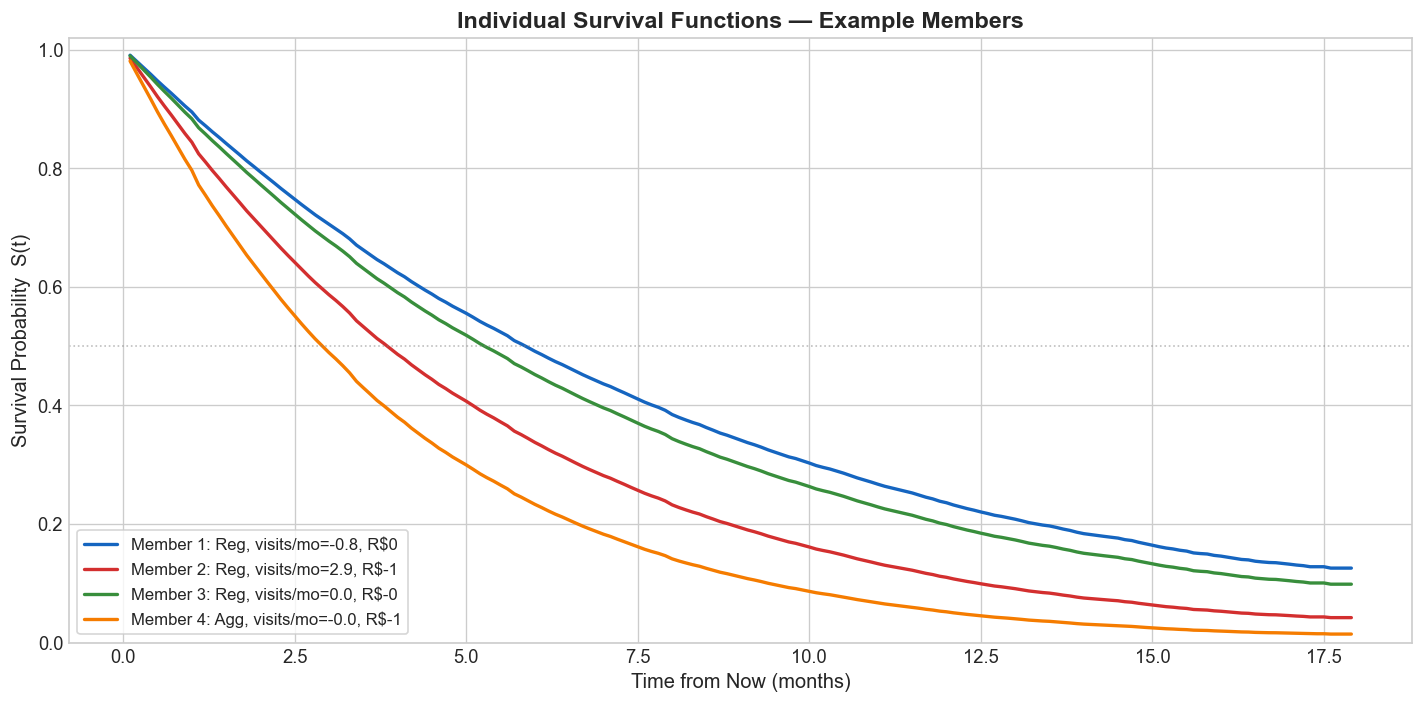

In [19]:
# ------------------------------------------------------------------
# Predict individual survival functions for example members
# ------------------------------------------------------------------
# Pick a diverse set of example members: low/mid/high risk
np.random.seed(42)

# Sample members from different risk profiles
sample_indices = []
if "is_aggregator" in cox_df.columns:
    # One aggregator, one regular, one high-frequency visitor, one low-frequency
    agg_idx = cox_df[cox_df["is_aggregator"] == 1].sample(1, random_state=42).index.tolist()
    reg_idx = cox_df[cox_df["is_aggregator"] == 0].sample(1, random_state=42).index.tolist()
    high_freq = cox_df.nlargest(100, "visit_frequency").sample(1, random_state=42).index.tolist()
    low_freq = cox_df[cox_df["visit_frequency"] > 0].nsmallest(100, "visit_frequency").sample(1, random_state=42).index.tolist()
    sample_indices = list(set(agg_idx + reg_idx + high_freq + low_freq))[:4]
else:
    sample_indices = cox_df.sample(4, random_state=42).index.tolist()

example_members = cox_df.loc[sample_indices]

# Predict survival functions
surv_funcs = cph.predict_survival_function(example_members)

fig, ax = plt.subplots(figsize=(12, 6))
colors_example = ["#1565C0", "#D32F2F", "#388E3C", "#F57C00"]

for i, (col, color) in enumerate(zip(surv_funcs.columns, colors_example)):
    member_data = example_members.loc[col]
    label_parts = []
    if "is_aggregator" in member_data.index:
        label_parts.append("Agg" if member_data["is_aggregator"] == 1 else "Reg")
    label_parts.append(f"visits/mo={member_data.get('visit_frequency', 0):.1f}")
    if "monthly_price" in member_data.index:
        label_parts.append(f"R${member_data['monthly_price']:.0f}")

    ax.plot(surv_funcs.index, surv_funcs[col], color=color, lw=2,
            label=f"Member {i+1}: {', '.join(label_parts)}")

ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)
ax.set_title("Individual Survival Functions — Example Members", fontweight="bold")
ax.set_xlabel("Time from Now (months)")
ax.set_ylabel("Survival Probability  S(t)")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left", frameon=True, fancybox=True)
plt.tight_layout()
plt.show()

In [20]:
# ------------------------------------------------------------------
# Compute LTV for each member in the dataset
# ------------------------------------------------------------------
ANNUAL_DISCOUNT_RATE = 0.12  # 12% annual — typical for Brazilian market
MONTHLY_DISCOUNT = 1 / (1 + ANNUAL_DISCOUNT_RATE / 12)
HORIZON_MONTHS = 36  # 3-year LTV horizon

# Get survival function predictions for all members
# We predict at monthly intervals out to HORIZON_MONTHS
time_points = np.arange(1, HORIZON_MONTHS + 1)

surv_all = cph.predict_survival_function(cox_df, times=time_points)

# Expected remaining tenure = area under the survival curve (sum of S(t) at each month)
expected_remaining_tenure = surv_all.sum(axis=0)  # sum across time for each member

# Discount factors: delta^1, delta^2, ..., delta^T
discount_factors = MONTHLY_DISCOUNT ** time_points

# If monthly_price is available, use it; otherwise use a placeholder
if "monthly_price" in members.columns:
    # Map monthly_price back to cox_df indices
    price_series = members.set_index(members.index)["monthly_price"].reindex(cox_df.index)
    price_series = price_series.fillna(price_series.median())
else:
    price_series = pd.Series(99.0, index=cox_df.index)  # placeholder R$99

# LTV = sum over t of S(t) * price * discount^t
# For each member: sum_t [ S_i(t) * price_i * delta^t ]
ltv_matrix = surv_all.values * discount_factors[:, np.newaxis]  # (T, N) * (T, 1) → (T, N)
ltv_per_member = (ltv_matrix * price_series.values[np.newaxis, :]).sum(axis=0)

cox_df["expected_remaining_tenure"] = expected_remaining_tenure.values
cox_df["ltv"] = ltv_per_member

print(f"LTV Calculation (horizon={HORIZON_MONTHS} months, discount={ANNUAL_DISCOUNT_RATE:.0%} annual)")
print("=" * 65)
print(f"  Mean LTV:   R${cox_df['ltv'].mean():,.0f}")
print(f"  Median LTV: R${cox_df['ltv'].median():,.0f}")
print(f"  Std LTV:    R${cox_df['ltv'].std():,.0f}")
print(f"  Min LTV:    R${cox_df['ltv'].min():,.0f}")
print(f"  Max LTV:    R${cox_df['ltv'].max():,.0f}")
print(f"\n  Mean expected remaining tenure: {cox_df['expected_remaining_tenure'].mean():.1f} months")

LTV Calculation (horizon=36 months, discount=12% annual)
  Mean LTV:   R$732
  Median LTV: R$691
  Std LTV:    R$437
  Min LTV:    R$2
  Max LTV:    R$2,327

  Mean expected remaining tenure: 7.5 months


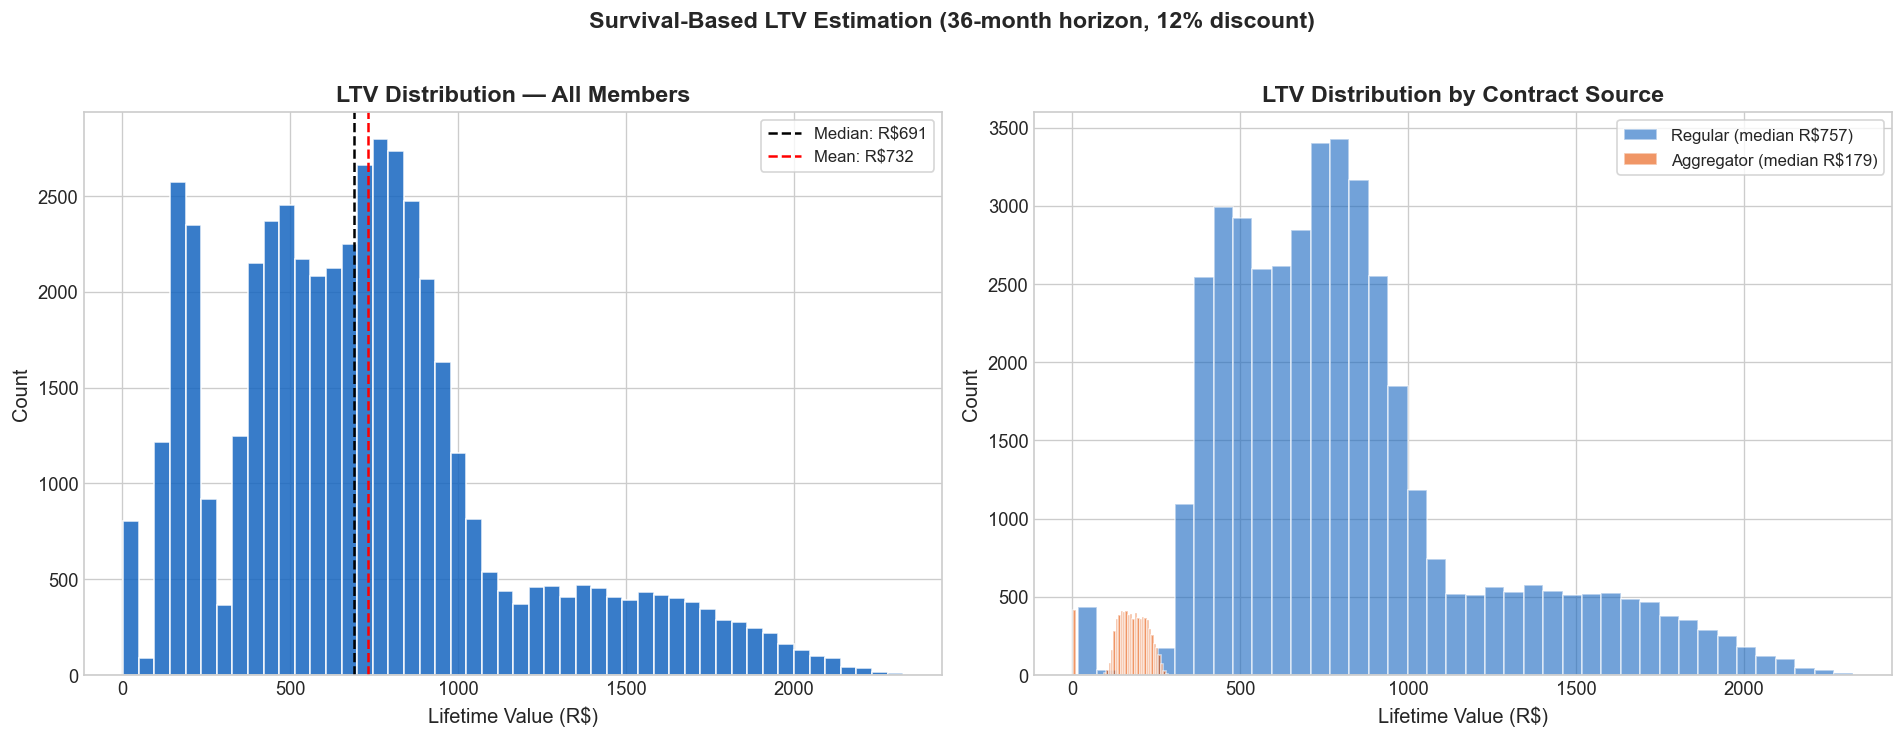


LTV Summary by Contract Source:
            Count  Mean LTV (R$)  Median LTV (R$)  Std LTV (R$)
Regular     42058          830.0            757.0         399.0
Aggregator   7426          174.0            179.0          57.0

Regular members have ~R$578 higher median LTV than aggregator members. This differential is a key input for the budget optimizer in src/optimization/.


In [21]:
# ------------------------------------------------------------------
# LTV distribution by segment
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Overall LTV distribution ---
ax = axes[0]
ax.hist(cox_df["ltv"], bins=50, edgecolor="white", color="#1565C0", alpha=0.85)
ax.axvline(cox_df["ltv"].median(), color="black", ls="--", lw=1.5,
           label=f'Median: R${cox_df["ltv"].median():,.0f}')
ax.axvline(cox_df["ltv"].mean(), color="red", ls="--", lw=1.5,
           label=f'Mean: R${cox_df["ltv"].mean():,.0f}')
ax.set_title("LTV Distribution — All Members", fontweight="bold")
ax.set_xlabel("Lifetime Value (R$)")
ax.set_ylabel("Count")
ax.legend(frameon=True)

# --- Panel 2: LTV by contract source ---
ax = axes[1]
if "is_aggregator" in cox_df.columns:
    for val, label, color in [(0, "Regular", "#1565C0"), (1, "Aggregator", "#E65100")]:
        subset = cox_df[cox_df["is_aggregator"] == val]["ltv"]
        ax.hist(subset, bins=40, alpha=0.6, edgecolor="white", color=color,
                label=f"{label} (median R${subset.median():,.0f})")

    ax.set_title("LTV Distribution by Contract Source", fontweight="bold")
    ax.set_xlabel("Lifetime Value (R$)")
    ax.set_ylabel("Count")
    ax.legend(frameon=True)
else:
    ax.text(0.5, 0.5, "contract_source not available", transform=ax.transAxes,
            ha="center", va="center", fontsize=12, color="gray")

fig.suptitle(
    f"Survival-Based LTV Estimation ({HORIZON_MONTHS}-month horizon, {ANNUAL_DISCOUNT_RATE:.0%} discount)",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

# Summary statistics by segment
if "is_aggregator" in cox_df.columns:
    print("\nLTV Summary by Contract Source:")
    print("=" * 50)
    ltv_summary = cox_df.groupby("is_aggregator")["ltv"].agg(["count", "mean", "median", "std"])
    ltv_summary.index = ["Regular", "Aggregator"]
    ltv_summary.columns = ["Count", "Mean LTV (R$)", "Median LTV (R$)", "Std LTV (R$)"]
    print(ltv_summary.round(0).to_string())
    reg_median = ltv_summary.loc["Regular", "Median LTV (R$)"]
    agg_median = ltv_summary.loc["Aggregator", "Median LTV (R$)"]
    diff = reg_median - agg_median
    print(
        f"\nRegular members have ~R${diff:,.0f} "
        f"{'higher' if diff > 0 else 'lower'} median LTV than aggregator members. "
        f"This differential is a key input for the budget optimizer in src/optimization/."
    )

## Key Takeaways

1. **Median survival** varies significantly by contract source. Regular (direct-signup) members have substantially longer median tenure than aggregator members. The overall median provides the baseline for retention KPIs.

2. **PH assumption violated for contract_source** — Schoenfeld residuals confirm that the aggregator effect is not constant over time. This validates ADR-003's decision to build separate models rather than a single model with a binary indicator. The hazard ratio for `is_aggregator` is an oversimplification; the real relationship is time-varying.

3. **Top hazard factors**: `days_since_last_visit` and `visit_frequency` are the strongest predictors of churn hazard. These are *actionable* — unlike age or contract source, we can influence visit behavior through interventions (nudges, class recommendations, re-engagement campaigns). This is directly relevant for the agent system in `src/agents/`.

4. **January cohorts** show higher early churn but converge after the initial high-risk window. Modeling implication: include enrollment-month interactions with early-tenure indicators in the production model (`src/models/`).

5. **LTV estimation requires survival model output** — binary churn models can't produce the survival curve $S(t)$ needed for the discounted expected revenue calculation. This is the core reason we chose survival analysis for RetentionIQ: it feeds directly into the Pyomo budget optimizer (`src/optimization/`) that allocates retention spend across 250+ locations.

---

**Next steps:**
- Notebook 03: Causal inference — do visits *cause* retention, or is it just selection? (DoWhy + EconML)
- Notebook 04: Treatment effect estimation — which members benefit most from interventions? (Causal forests)
- Production model training in `src/models/` with temporal train/test splits (no random splits — see CLAUDE.md)